# Layer-to-Layer Hidden State Affine Mapping

Questions: For tokens that stabilize early according to TunedLens, can we can learn a simple mapping for what the layer-wise update is between hidden state representation at layer l and l + 1?

This first version focuses on:
- loading excerpt files
- validating schema and tensor shapes
- producing reusable per-excerpt parsed objects for downstream modeling

## Data Loading Pipeline

In [21]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import numpy as np
from transformers import AutoTokenizer

MODEL_NAME = "EleutherAI/pythia-160m-deduped"

# Fixed data path for this notebook
DATA_ROOT = Path("/Users/anjali/Library/CloudStorage/GoogleDrive-anjalisr@stanford.edu/My Drive/depth_routing_data/token_evolution_data")
EXCERPT_DIR = DATA_ROOT / "excerpts"
N_LAYERS = 13  # embedding + 12 transformer blocks for pythia-160m

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"MODEL_NAME:  {MODEL_NAME}")
print(f"DATA_ROOT:   {DATA_ROOT}")
print(f"EXCERPT_DIR: {EXCERPT_DIR}")

excerpt_files = sorted(EXCERPT_DIR.glob("excerpt_*.npz"))
print(f"Found {len(excerpt_files):,} excerpt files")

if not excerpt_files:
    raise FileNotFoundError(
        f"No excerpt_*.npz files found in: {EXCERPT_DIR}"
    )

/Users/anjali/Library/CloudStorage/OneDrive-Stanford/Coursework/Year 3/Winter/CS 224N/depth-routing/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MODEL_NAME:  EleutherAI/pythia-160m-deduped
DATA_ROOT:   /Users/anjali/Library/CloudStorage/GoogleDrive-anjalisr@stanford.edu/My Drive/depth_routing_data/token_evolution_data
EXCERPT_DIR: /Users/anjali/Library/CloudStorage/GoogleDrive-anjalisr@stanford.edu/My Drive/depth_routing_data/token_evolution_data/excerpts
Found 1,605 excerpt files


In [ ]:
REQUIRED_KEYS = {
    "hidden_states",      # (13, seq_len, d_model)
    "tl_top_token_ids",   # (13, seq_len)
    "token_losses",       # (seq_len - 1,)
    "input_ids",          # (seq_len,)
}

@dataclass
class ExcerptBatch:
    path: Path
    hidden_states: np.ndarray
    tl_top_token_ids: np.ndarray
    token_losses: np.ndarray
    input_ids: np.ndarray

    @property
    def seq_len(self) -> int:
        return int(self.hidden_states.shape[1])

    @property
    def d_model(self) -> int:
        return int(self.hidden_states.shape[2])


def load_excerpt_npz(path: Path) -> ExcerptBatch:
    """Load one excerpt and run sanity checks."""
    data = np.load(path, allow_pickle=True)

    missing = REQUIRED_KEYS.difference(set(data.files))
    if missing:
        raise KeyError(f"{path.name}: missing keys {sorted(missing)}")

    hs = np.asarray(data["hidden_states"], dtype=np.float32)
    top = np.asarray(data["tl_top_token_ids"])
    losses = np.asarray(data["token_losses"], dtype=np.float32)
    ids = np.asarray(data["input_ids"])
    
    seq_len = hs.shape[1]
    if top.shape != (N_LAYERS, seq_len):
        raise ValueError(
            f"{path.name}: tl_top_token_ids shape mismatch. "
            f"Expected {(N_LAYERS, seq_len)}, got {top.shape}"
        )
    if ids.shape != (seq_len,):
        raise ValueError(f"{path.name}: input_ids shape mismatch, got {ids.shape}")
    if losses.shape != (seq_len - 1,):
        raise ValueError(
            f"{path.name}: token_losses shape mismatch. "
            f"Expected {(seq_len - 1,)}, got {losses.shape}"
        )

    if not np.all(np.isfinite(hs)):
        raise ValueError(f"{path.name}: hidden_states contains non-finite values")
    if not np.all(np.isfinite(losses)):
        raise ValueError(f"{path.name}: token_losses contains non-finite values")

    return ExcerptBatch(
        path=path,
        hidden_states=hs,
        tl_top_token_ids=top,
        token_losses=losses,
        input_ids=ids,
    )

In [26]:
# Quick single-file sanity check
sample = load_excerpt_npz(excerpt_files[0])

print("Single-file sanity check")
print(f"  file:      {sample.path.name}")
print(f"  hs shape:  {sample.hidden_states.shape}")
print(f"  top shape: {sample.tl_top_token_ids.shape}")
print(f"  ids shape: {sample.input_ids.shape}")
print(f"  loss shape:{sample.token_losses.shape}")
print(f"  d_model:   {sample.d_model}")

assert sample.seq_len > 1, "Need at least 2 tokens to define next-token losses"
assert sample.d_model > 0
assert sample.token_losses.min() >= 0, "Cross-entropy losses should be non-negative"

Single-file sanity check
  file:      excerpt_0000.npz
  hs shape:  (13, 185, 768)
  top shape: (13, 185)
  ids shape: (185,)
  loss shape:(184,)
  d_model:   768


In [25]:
def compute_stabilization_layer(top_ids: np.ndarray) -> np.ndarray:
    """Return per-token earliest layer where top-1 matches final layer thereafter.

    top_ids: (N_LAYERS, seq_len)
    returns: (seq_len,) integer layer index in [0, N_LAYERS-1]
    """
    if top_ids.shape[0] != N_LAYERS:
        raise ValueError(f"Expected {N_LAYERS} layers, got {top_ids.shape[0]}")

    matches_final = top_ids == top_ids[-1:]
    cumulative = np.cumprod(matches_final[::-1], axis=0)[::-1]
    first_stable_layer = np.argmax(cumulative, axis=0)
    return first_stable_layer


def get_category_masks(stabilization_layer: np.ndarray) -> dict[str, np.ndarray]:
    return {
        "never": stabilization_layer == (N_LAYERS - 1),
        "by_4": stabilization_layer <= 4,
        "by_0": stabilization_layer == 0,
    }


# Example usage on one file (drop last token to align with token_losses)
top_work = sample.tl_top_token_ids[:, :-1]
st_layer = compute_stabilization_layer(top_work)
masks = get_category_masks(st_layer)

target_token_ids = sample.input_ids[1:]
by_0_token_ids = target_token_ids[masks["by_0"]]
by_0_tokens = [repr(tokenizer.decode([int(token_id)])) for token_id in by_0_token_ids]

print("Category counts on sample file:")
for k, v in masks.items():
    print(f"  {k:>5}: {int(v.sum()):,}")

print("\nTarget tokens that stabilize by layer 0:")
for token_id, token_str in zip(by_0_token_ids.tolist(), by_0_tokens):
    print(f"  {token_id:>6}  {token_str}")

unique_ids, counts = np.unique(by_0_token_ids, return_counts=True)
order = np.argsort(counts)[::-1]

Category counts on sample file:
  never: 123
   by_4: 37
   by_0: 19

Target tokens that stabilize by layer 0:
    1157  ' ,'
    1157  ' ,'
     253  ' the'
     273  ' of'
     253  ' the'
    9011  ' Sir'
     253  ' the'
    5215  ' 2007'
      15  '.'
     247  ' a'
     273  ' of'
     253  ' the'
     320  ' be'
    4439  ' released'
     273  ' of'
   13126  ' Product'
    8140  'iously'
     253  ' the'
     320  ' be'


## Next step

With this loader in place, the next section can construct supervised datasets for transitions $h_l \to h_{l+1}$ (optionally per stabilization category) and fit affine maps layer-by-layer.

## Linear Maps For Hidden-State Updates

We fit one affine map per layer transition using hidden-state updates
$\Delta h_l = h_{l+1} - h_l$.

The same pipeline is used for different token categories so we can compare easy tokens (`by_0`) against hard tokens (`never`).

In [40]:
from dataclasses import dataclass
import csv

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

RNG_SEED = 0
MAX_FILES = 200
MAX_TOKENS_PER_CATEGORY = 12000
TRAIN_FRACTION = 0.9
ARTIFACTS_DIR = Path("./affine_map_artifacts")


# Stores sampled token trajectories for one category, along with metadata about their source files
@dataclass
class UpdateDataset:
    category: str
    states: np.ndarray          # (n_tokens, N_LAYERS, d_model)
    token_ids: np.ndarray       # (n_tokens,)
    source_files: list[str]


# Stores the fitted model and metrics for one layer transition
@dataclass
class LayerFitResult:
    layer: int
    model: LinearRegression
    X: np.ndarray
    Y: np.ndarray
    X_hat: np.ndarray
    Y_hat: np.ndarray
    delta_pred: np.ndarray
    next_pred: np.ndarray
    update_mse: float
    update_r2: float
    next_state_mse: float


def sample_token_states(
    category: str,
    *,
    max_files: int = MAX_FILES,
    max_tokens: int = MAX_TOKENS_PER_CATEGORY,
    seed: int = RNG_SEED,
) -> UpdateDataset:
    """Randomly sample token trajectories for one stabilization category."""
    rng = np.random.default_rng(seed)
    chosen_states = []
    chosen_token_ids = []
    source_files = []

    print(f"\n[sample] category={category!r} | scanning up to {max_files} files")

    for file_idx, fpath in enumerate(excerpt_files[:max_files], start=1):
        if file_idx % 50 == 0:
            print(
                f"[sample] {category}: processed {file_idx}/{min(max_files, len(excerpt_files))} files | "
                f"collected {len(chosen_states):,} tokens"
            )

        batch = load_excerpt_npz(fpath)
        top_work = batch.tl_top_token_ids[:, :-1]
        st_layer = compute_stabilization_layer(top_work)
        mask = get_category_masks(st_layer)[category]

        if not np.any(mask):
            continue

        states = np.transpose(batch.hidden_states[:, :-1, :], (1, 0, 2))
        token_ids = batch.input_ids[1:]

        idx = np.flatnonzero(mask)
        rng.shuffle(idx)

        remaining = max_tokens - len(chosen_states)
        if remaining <= 0:
            print(f"[sample] {category}: reached token cap ({max_tokens:,})")
            break

        idx = idx[:remaining]
        chosen_states.extend(states[idx])
        chosen_token_ids.extend(token_ids[idx])
        source_files.extend([fpath.name] * len(idx))

    if not chosen_states:
        raise ValueError(f"No tokens collected for category={category!r}")

    states_arr = np.stack(chosen_states).astype(np.float32)
    token_ids_arr = np.asarray(chosen_token_ids)

    if states_arr.ndim != 3 or states_arr.shape[1] != N_LAYERS:
        raise ValueError(f"Unexpected state tensor shape: {states_arr.shape}")
    if not np.all(np.isfinite(states_arr)):
        raise ValueError("Collected states contain non-finite values")

    print(f"[sample] done | category={category} | tokens={len(states_arr):,} | state_shape={states_arr.shape}")

    return UpdateDataset(
        category=category,
        states=states_arr,
        token_ids=token_ids_arr,
        source_files=source_files,
    )


def split_states(states: np.ndarray, *, train_fraction: float = TRAIN_FRACTION) -> tuple[np.ndarray, np.ndarray]:
    """Random train/test split at the token level."""
    if not 0 < train_fraction < 1:
        raise ValueError("train_fraction must lie strictly between 0 and 1")
    if len(states) < 2:
        raise ValueError("Need at least 2 token trajectories to make a split")

    rng = np.random.default_rng(RNG_SEED)
    perm = rng.permutation(len(states))
    cut = int(train_fraction * len(states))
    cut = min(max(cut, 1), len(states) - 1)

    train_states = states[perm[:cut]]
    test_states = states[perm[cut:]]

    return train_states, test_states


def build_transition_data(states: np.ndarray, layer: int) -> tuple[np.ndarray, np.ndarray]:
    """Build X=h_l and Y=h_{l+1}-h_l for one layer transition."""
    if not 0 <= layer < N_LAYERS - 1:
        raise ValueError(f"Layer must be in [0, {N_LAYERS - 2}], got {layer}")

    X = states[:, layer, :]
    Y = states[:, layer + 1, :] - states[:, layer, :]

    if X.shape != Y.shape:
        raise ValueError(f"Shape mismatch: X={X.shape}, Y={Y.shape}")

    return X, Y


def fit_update_maps(dataset: UpdateDataset) -> list[LayerFitResult]:
    """Fit 12 separate affine maps for one category."""
    train_states, test_states = split_states(dataset.states)
    results = []

    print(
        f"\n[fit] category={dataset.category!r} | "
        f"train_tokens={len(train_states):,} | test_tokens={len(test_states):,}"
    )

    for layer in range(N_LAYERS - 1):
        print(f"[fit] {dataset.category}: training layer {layer} -> {layer + 1}")
        X, Y = build_transition_data(train_states, layer)
        X_hat, Y_hat = build_transition_data(test_states, layer)

        model = LinearRegression()
        model.fit(X, Y)

        delta_pred = model.predict(X_hat)
        next_pred = X_hat + delta_pred
        next_true = X_hat + Y_hat

        results.append(
            LayerFitResult(
                layer=layer,
                model=model,
                X=X,
                Y=Y,
                X_hat=X_hat,
                Y_hat=Y_hat,
                delta_pred=delta_pred,
                next_pred=next_pred,
                update_mse=mean_squared_error(Y_hat, delta_pred),
                update_r2=r2_score(Y_hat, delta_pred),
                next_state_mse=mean_squared_error(next_true, next_pred),
            )
        )

    print(f"[fit] done | category={dataset.category} | fitted_maps={len(results)}")
    return results


def summarize_fit(results: list[LayerFitResult], *, label: str) -> None:
    print(f"\nCategory: {label}")
    print(f"{'Layer':>5}  {'n_train':>7}  {'n_test':>6}  {'update_mse':>12}  {'update_r2':>10}  {'next_mse':>12}")
    for res in results:
        print(
            f"{res.layer:5d}  {len(res.X):7d}  {len(res.X_hat):6d}  "
            f"{res.update_mse:12.6f}  {res.update_r2:10.4f}  {res.next_state_mse:12.6f}"
        )


def show_sample_tokens(dataset: UpdateDataset, n: int = 15) -> None:
    print(f"\nSample decoded tokens for {dataset.category}:")
    for token_id in dataset.token_ids[:n]:
        print(f"  {int(token_id):>6}  {repr(tokenizer.decode([int(token_id)]))}")


def write_affine_artifacts(results: list[LayerFitResult], *, label: str, output_root: Path = ARTIFACTS_DIR) -> tuple[Path, Path]:
    """Write per-layer affine parameters and a summary CSV to disk."""
    group_dir = output_root / label
    layer_dir = group_dir / "layer_params"
    layer_dir.mkdir(parents=True, exist_ok=True)

    summary_rows = []
    for res in results:
        coef = res.model.coef_       # (d_model, d_model)
        intercept = res.model.intercept_  # (d_model,)

        layer_file = layer_dir / f"layer_{res.layer:02d}_to_{res.layer+1:02d}.npz"
        np.savez_compressed(
            layer_file,
            layer=res.layer,
            coef=coef,
            intercept=intercept,
            update_mse=res.update_mse,
            update_r2=res.update_r2,
            next_state_mse=res.next_state_mse,
            n_train=len(res.X),
            n_test=len(res.X_hat),
        )

        summary_rows.append({
            "layer": res.layer,
            "n_train": len(res.X),
            "n_test": len(res.X_hat),
            "update_mse": res.update_mse,
            "update_r2": res.update_r2,
            "next_state_mse": res.next_state_mse,
            "coef_fro_norm": float(np.linalg.norm(coef)),
            "intercept_l2_norm": float(np.linalg.norm(intercept)),
        })

    summary_file = group_dir / "summary_metrics.csv"
    with summary_file.open("w", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "layer",
                "n_train",
                "n_test",
                "update_mse",
                "update_r2",
                "next_state_mse",
                "coef_fro_norm",
                "intercept_l2_norm",
            ],
        )
        writer.writeheader()
        writer.writerows(summary_rows)

    print(f"[write] saved affine parameters to: {layer_dir}")
    print(f"[write] saved summary metrics to:   {summary_file}")
    return layer_dir, summary_file

In [41]:
by_0_dataset = sample_token_states("by_0")
print("Done sampling tokens for by_0 category.")
show_sample_tokens(by_0_dataset)

print(f"\nCollected {len(by_0_dataset.states):,} token trajectories for by_0")
print(f"State tensor shape: {by_0_dataset.states.shape}")

by_0_results = fit_update_maps(by_0_dataset)
summarize_fit(by_0_results, label="by_0")
by_0_layer_dir, by_0_summary_file = write_affine_artifacts(by_0_results, label="by_0")

assert len(by_0_results) == N_LAYERS - 1
assert all(res.X.shape[1] == sample.d_model for res in by_0_results)
assert all(np.isfinite(res.update_mse) for res in by_0_results)


[sample] category='by_0' | scanning up to 200 files
[sample] by_0: processed 50/200 files | collected 335 tokens
[sample] by_0: processed 100/200 files | collected 861 tokens
[sample] by_0: processed 150/200 files | collected 1,359 tokens
[sample] by_0: processed 200/200 files | collected 1,903 tokens
[sample] done | category=by_0 | tokens=1,919 | state_shape=(1919, 13, 768)
Done sampling tokens for by_0 category.

Sample decoded tokens for by_0:
    5307  ' 2000'
     253  ' the'
     346  ' "'
     253  ' the'
   12936  ' alongside'
     271  ' an'
     754  ' He'
    4596  ' November'
     253  ' the'
    1359  ' How'
     275  ' in'
    1157  ' ,'
     253  ' the'
     380  ' The'
     378  ' B'

Collected 1,919 token trajectories for by_0
State tensor shape: (1919, 13, 768)

[fit] category='by_0' | train_tokens=1,727 | test_tokens=192
[fit] by_0: training layer 0 -> 1
[fit] by_0: training layer 1 -> 2
[fit] by_0: training layer 2 -> 3
[fit] by_0: training layer 3 -> 4
[fit] by_0:

In [42]:
never_dataset = sample_token_states("never")
print("Done sampling tokens for never category.")
show_sample_tokens(never_dataset)

print(f"\nCollected {len(never_dataset.states):,} token trajectories for never")
print(f"State tensor shape: {never_dataset.states.shape}")

never_results = fit_update_maps(never_dataset)
summarize_fit(never_results, label="never")
never_layer_dir, never_summary_file = write_affine_artifacts(never_results, label="never")

assert len(never_results) == N_LAYERS - 1
assert all(res.X.shape[1] == sample.d_model for res in never_results)
assert all(np.isfinite(res.update_mse) for res in never_results)


[sample] category='never' | scanning up to 200 files
[sample] never: processed 50/200 files | collected 3,059 tokens
[sample] never: processed 100/200 files | collected 7,232 tokens
[sample] never: processed 150/200 files | collected 10,750 tokens
[sample] never: reached token cap (12,000)
[sample] done | category=never | tokens=12,000 | state_shape=(12000, 13, 768)
Done sampling tokens for never category.

Sample decoded tokens for never:
   28193  ' starring'
    2962  ' series'
   28193  ' starring'
   24747  ' Strong'
     964  ' .'
   12808  ' Kent'
   38541  ' Firm'
    3560  ' followed'
     964  ' .'
     763  'ish'
   36312  ' Derek'
      14  '-'
     273  ' of'
     964  ' .'
    6029  ' Ben'

Collected 12,000 token trajectories for never
State tensor shape: (12000, 13, 768)

[fit] category='never' | train_tokens=10,800 | test_tokens=1,200
[fit] never: training layer 0 -> 1
[fit] never: training layer 1 -> 2
[fit] never: training layer 2 -> 3
[fit] never: training layer 3 -

Layer-by-layer comparison: by_0 vs never
Layer    by_0 R^2   never R^2      by_0 MSE     never MSE
    0      0.7178      0.8044      0.017523      0.014661
    1     -2.2963      0.4348      0.118379      0.018630
    2      0.0571      0.5134      0.059812      0.030365
    3      0.2433      0.5792      0.075904      0.053218
    4      0.3948      0.5703      0.037483      0.028031
    5      0.4470      0.6329      0.037811      0.027314
    6      0.5420      0.6770      0.040097      0.027788
    7      0.6336      0.7213      0.049025      0.034399
    8      0.6149      0.7203      0.063858      0.040952
    9      0.6753      0.7205      0.068571      0.051890
   10      0.5594      0.6597      0.081540      0.066637
   11      0.5658      0.6525      0.176508      0.325680

Saved comparison plot to: affine_map_artifacts/by0_vs_never_prediction_stats.png


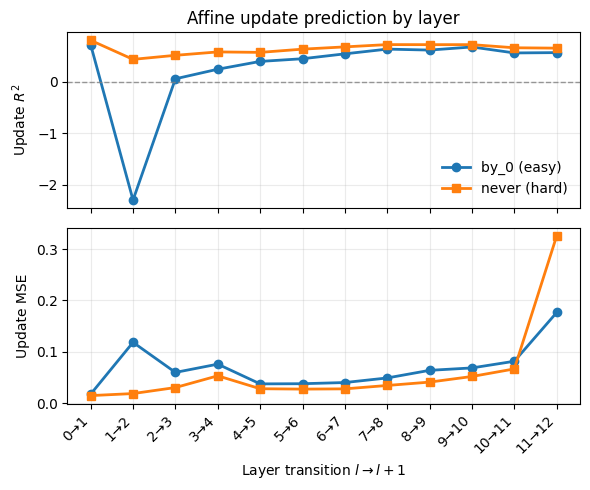

In [43]:
import matplotlib.pyplot as plt

layers = np.arange(N_LAYERS - 1)
by0_r2 = np.array([res.update_r2 for res in by_0_results])
never_r2 = np.array([res.update_r2 for res in never_results])
by0_mse = np.array([res.update_mse for res in by_0_results])
never_mse = np.array([res.update_mse for res in never_results])

print("Layer-by-layer comparison: by_0 vs never")
print(f"{'Layer':>5}  {'by_0 R^2':>10}  {'never R^2':>10}  {'by_0 MSE':>12}  {'never MSE':>12}")
for layer, r2_easy, r2_hard, mse_easy, mse_hard in zip(layers, by0_r2, never_r2, by0_mse, never_mse):
    print(f"{layer:5d}  {r2_easy:10.4f}  {r2_hard:10.4f}  {mse_easy:12.6f}  {mse_hard:12.6f}")

fig, axes = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

# Top panel: update R^2
ax = axes[0]
ax.plot(layers, by0_r2, marker="o", linewidth=2, label="by_0 (easy)")
ax.plot(layers, never_r2, marker="s", linewidth=2, label="never (hard)")
ax.axhline(0.0, linestyle="--", linewidth=1, color="gray", alpha=0.8)
ax.set_ylabel("Update $R^2$")
ax.set_title("Affine update prediction by layer")
ax.legend(frameon=False)
ax.grid(alpha=0.25)

# Bottom panel: update MSE
ax = axes[1]
ax.plot(layers, by0_mse, marker="o", linewidth=2, label="by_0 (easy)")
ax.plot(layers, never_mse, marker="s", linewidth=2, label="never (hard)")
ax.set_xlabel("Layer transition $l \\to l+1$")
ax.set_ylabel("Update MSE")
ax.grid(alpha=0.25)

xtick_labels = [f"{l}→{l+1}" for l in layers]
axes[1].set_xticks(layers)
axes[1].set_xticklabels(xtick_labels, rotation=45, ha="right")

fig.tight_layout()
plot_path = ARTIFACTS_DIR / "by0_vs_never_prediction_stats.png"
plot_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
print(f"\nSaved comparison plot to: {plot_path}")
plt.show()

In [44]:
# Compact diagnostic summary for by_0 fit results
import numpy as np

r2 = np.array([res.update_r2 for res in by_0_results])
mse = np.array([res.update_mse for res in by_0_results])

print("by_0 summary")
print(f"  mean update_r2:   {r2.mean():.4f}")
print(f"  median update_r2: {np.median(r2):.4f}")
print(f"  min update_r2:    {r2.min():.4f} (layer {int(r2.argmin())} -> {int(r2.argmin()+1)})")
print(f"  max update_r2:    {r2.max():.4f} (layer {int(r2.argmax())} -> {int(r2.argmax()+1)})")
print(f"  mse range:        [{mse.min():.6f}, {mse.max():.6f}]")

print("\nPer-layer update_r2:")
for l, v in enumerate(r2):
    print(f"  {l:2d}->{l+1:2d}: {v:.4f}")

by_0 summary
  mean update_r2:   0.2629
  median update_r2: 0.5507
  min update_r2:    -2.2963 (layer 1 -> 2)
  max update_r2:    0.7178 (layer 0 -> 1)
  mse range:        [0.017523, 0.176508]

Per-layer update_r2:
   0-> 1: 0.7178
   1-> 2: -2.2963
   2-> 3: 0.0571
   3-> 4: 0.2433
   4-> 5: 0.3948
   5-> 6: 0.4470
   6-> 7: 0.5420
   7-> 8: 0.6336
   8-> 9: 0.6149
   9->10: 0.6753
  10->11: 0.5594
  11->12: 0.5658
